/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


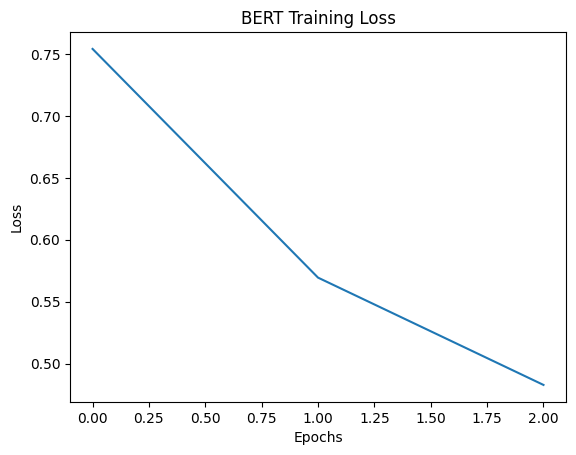

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import matplotlib.pyplot as plt
# Dataset
texts = ["I love this", "Worst product", "Amazing service", "Bad experience"]
labels = torch.tensor([1, 0, 1, 0])

# Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
# Model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased')

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

losses = []
# Training
for epoch in range(3):
    outputs = model(**inputs, labels=labels)
    loss = outputs.loss
    losses.append(loss.item())

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
# Plot Loss
plt.plot(losses)
plt.title("BERT Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()